## Import Libraries

In [14]:
#  Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import sys
import os
sys.path.append('..')
from src.parser import ResumeParser
from src.preprocess import TextPreprocessor
from src.similarity import SimilarityCalculator
from src.ranking import CandidateRanker
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("Libraries imported successfully!")


Libraries imported successfully!


In [15]:
# Load Processed Data

# Define paths
resume_dir = '../data/resumes/'
jd_dir = '../data/job_descriptions/'
output_dir = '../output/'
charts_dir = '../output/charts/'
images_dir = '../images/'

os.makedirs(output_dir, exist_ok=True)
os.makedirs(charts_dir, exist_ok=True)
os.makedirs(images_dir, exist_ok=True)

# Initialize components
parser = ResumeParser()
preprocessor = TextPreprocessor()
similarity = SimilarityCalculator()
ranker = CandidateRanker()

# Load resumes
resume_files = [f for f in os.listdir(resume_dir) if f.endswith('.pdf')]
print(f"Found {len(resume_files)} resumes")

# Load job descriptions
jd_files = [f for f in os.listdir(jd_dir) if f.endswith('.txt')]
print(f"Found {len(jd_files)} job descriptions")


Found 40 resumes
Found 5 job descriptions


In [16]:
# Parse and Preprocess All Resumes

resume_data = []
for resume_file in resume_files:
    filepath = os.path.join(resume_dir, resume_file)
    text = parser.extract_text(filepath)

    # Clean text
    cleaned_text = preprocessor.clean_text(text)

    # Tokenize, remove stopwords, lemmatize
    tokens = preprocessor.tokenize(cleaned_text)
    filtered = preprocessor.remove_stopwords(tokens)
    lemmatized = preprocessor.lemmatize(filtered)

    resume_data.append({
        'file': resume_file,
        'original_text': text,
        'cleaned_text': cleaned_text,
        'tokens': lemmatized,
        'full_text': ' '.join(lemmatized)
    })

print(f"Processed {len(resume_data)} resumes")

Processed 40 resumes


In [17]:
#  Parse and Preprocess Job Descriptions

jd_data = []
for jd_file in jd_files:
    filepath = os.path.join(jd_dir, jd_file)
    with open(filepath, 'r', encoding='utf-8') as f:
        text = f.read()

    # Clean text
    cleaned_text = preprocessor.clean_text(text)

    # Tokenize, remove stopwords, lemmatize
    tokens = preprocessor.tokenize(cleaned_text)
    filtered = preprocessor.remove_stopwords(tokens)
    lemmatized = preprocessor.lemmatize(filtered)

    jd_data.append({
        'file': jd_file,
        'original_text': text,
        'cleaned_text': cleaned_text,
        'tokens': lemmatized,
        'full_text': ' '.join(lemmatized)
    })

print(f"Processed {len(jd_data)} job descriptions")

Processed 5 job descriptions


In [18]:
# Create TF-IDF Vectors for All Documents
def create_tfidf_vectors(documents):
    """Create TF-IDF vectors for documents"""
    vectorizer = TfidfVectorizer(
        max_features=5000,
        stop_words='english',
        ngram_range=(1, 2)
    )
    vectors = vectorizer.fit_transform(documents)
    return vectors, vectorizer

# Combine all documents for TF-IDF
all_documents = [d['full_text'] for d in resume_data] + [d['full_text'] for d in jd_data]
all_vectors, tfidf_vectorizer = create_tfidf_vectors(all_documents)

print(f"TF-IDF Matrix Shape: {all_vectors.shape}")
print(f"Number of features: {len(tfidf_vectorizer.get_feature_names_out())}")

# Split vectors
resume_vectors = all_vectors[:len(resume_data)]
jd_vectors = all_vectors[len(resume_data):]

print(f"Resume vectors: {resume_vectors.shape}")
print(f"JD vectors: {jd_vectors.shape}")


TF-IDF Matrix Shape: (45, 1319)
Number of features: 1319
Resume vectors: (40, 1319)
JD vectors: (5, 1319)


In [19]:
#  Create TF-IDF Vectors for All Documents

def create_tfidf_vectors(documents):
    """Create TF-IDF vectors for documents"""
    vectorizer = TfidfVectorizer(
        max_features=5000,
        stop_words='english',
        ngram_range=(1, 2)
    )
    vectors = vectorizer.fit_transform(documents)
    return vectors, vectorizer

# Combine all documents for TF-IDF
all_documents = [d['full_text'] for d in resume_data] + [d['full_text'] for d in jd_data]
all_vectors, tfidf_vectorizer = create_tfidf_vectors(all_documents)

print(f"TF-IDF Matrix Shape: {all_vectors.shape}")
print(f"Number of features: {len(tfidf_vectorizer.get_feature_names_out())}")

# Split vectors
resume_vectors = all_vectors[:len(resume_data)]
jd_vectors = all_vectors[len(resume_data):]

print(f"Resume vectors: {resume_vectors.shape}")
print(f"JD vectors: {jd_vectors.shape}")


TF-IDF Matrix Shape: (45, 1319)
Number of features: 1319
Resume vectors: (40, 1319)
JD vectors: (5, 1319)


In [20]:
#  Calculate Similarity Scores

def calculate_similarity_scores(resume_vectors, jd_vectors):
    """Calculate similarity between resumes and job descriptions"""
    similarity_scores = cosine_similarity(resume_vectors, jd_vectors)
    return similarity_scores

similarity_matrix = calculate_similarity_scores(resume_vectors, jd_vectors)
print(f"Similarity Matrix Shape: {similarity_matrix.shape}")

Similarity Matrix Shape: (40, 5)


In [21]:
#  Create Results for First Job Description

jd_index = 0  # Using first JD for demonstration
jd_name = jd_data[jd_index]['file'].replace('.txt', '').replace('_', ' ').title()

# Get scores for this JD
scores = similarity_matrix[:, jd_index]

# Create results DataFrame
results = pd.DataFrame({
    'Candidate': [r['file'].replace('.pdf', '').replace('_', ' ').title() for r in resume_data],
    'File': [r['file'] for r in resume_data],
    'Similarity_Score': scores * 100  # Convert to percentage
})

# Sort by score
results = results.sort_values('Similarity_Score', ascending=False).reset_index(drop=True)
results['Rank'] = range(1, len(results) + 1)

print(f"Results for: {jd_name}")
results.head(10)


Results for: Backend Developer Jd


,Candidate,File,Similarity_Score,Rank
0,Shahid Farooq Backend Developer 7,Shahid_Farooq_Backend_Developer_7.pdf,21.573768,1
1,Sana Khan Backend Developer 2,Sana_Khan_Backend_Developer_2.pdf,19.124331,2
2,Mahnoor Khan Backend Developer 1,Mahnoor_Khan_Backend_Developer_1.pdf,19.073038,3
3,Junaid Sheikh Backend Developer 6,Junaid_Sheikh_Backend_Developer_6.pdf,16.994184,4
4,Adeel Abbasi Backend Developer 3,Adeel_Abbasi_Backend_Developer_3.pdf,16.911746,5
5,Imran Raza Backend Developer 8,Imran_Raza_Backend_Developer_8.pdf,14.908859,6
6,Rabia Farooq Backend Developer 4,Rabia_Farooq_Backend_Developer_4.pdf,11.586235,7
7,Iqra Raza Mern Developer 4,Iqra_Raza_MERN_Developer_4.pdf,11.573383,8
8,Mariam Qureshi Backend Developer 5,Mariam_Qureshi_Backend_Developer_5.pdf,10.692830,9
9,Ali Abbasi Mern Developer 7,Ali_Abbasi_MERN_Developer_7.pdf,6.833296,10


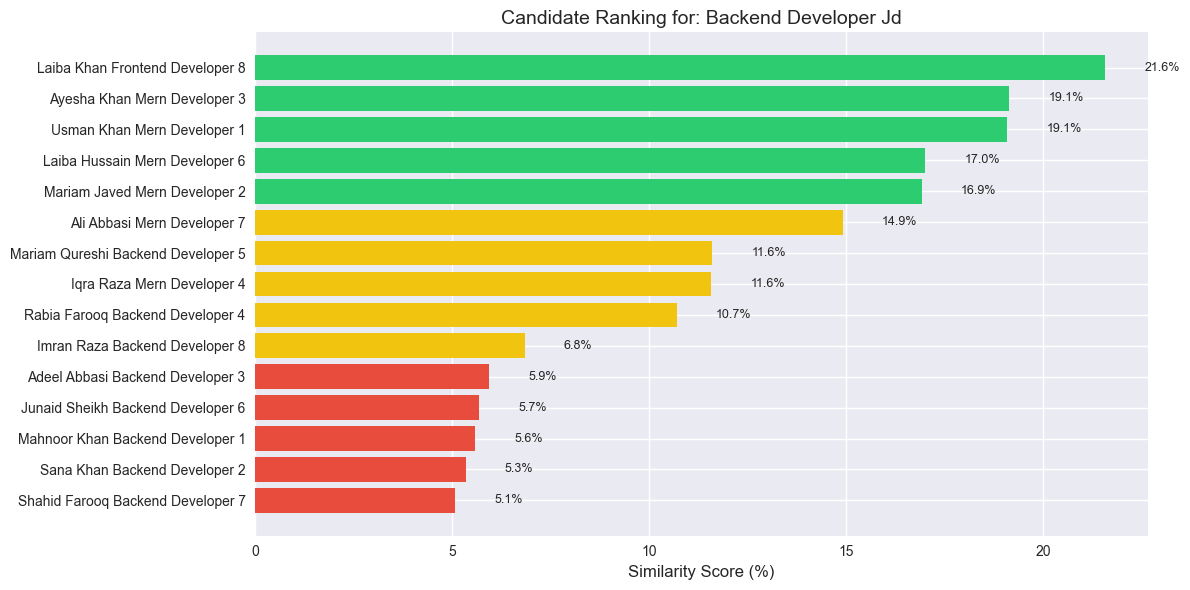

In [22]:
#  Ranking Visualization for Top Candidates

fig, ax = plt.subplots(figsize=(12, 6))

top_n = min(15, len(results))
top_results = results.head(top_n)

colors = ['#2ecc71' if i < 5 else '#f1c40f' if i < 10 else '#e74c3c' for i in range(len(top_results))]
bars = ax.barh(range(len(top_results)), top_results['Similarity_Score'], color=colors)

ax.set_yticks(range(len(top_results)))
ax.set_yticklabels(top_results['Candidate'][::-1])
ax.set_xlabel('Similarity Score (%)', fontsize=12)
ax.set_title(f'Candidate Ranking for: {jd_name}', fontsize=14)
ax.invert_yaxis()

# Add score labels
for i, (bar, score) in enumerate(zip(bars, top_results['Similarity_Score'])):
    ax.text(score + 1, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}%', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{images_dir}/candidate_ranking.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Save Rankings to CSV

output_path = os.path.join(output_dir, 'ranked_candidates.csv')
results.to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")
results.head()



Results saved to: ../output/ranked_candidates.csv


,Candidate,File,Similarity_Score,Rank
0,Shahid Farooq Backend Developer 7,Shahid_Farooq_Backend_Developer_7.pdf,21.573768,1
1,Sana Khan Backend Developer 2,Sana_Khan_Backend_Developer_2.pdf,19.124331,2
2,Mahnoor Khan Backend Developer 1,Mahnoor_Khan_Backend_Developer_1.pdf,19.073038,3
3,Junaid Sheikh Backend Developer 6,Junaid_Sheikh_Backend_Developer_6.pdf,16.994184,4
4,Adeel Abbasi Backend Developer 3,Adeel_Abbasi_Backend_Developer_3.pdf,16.911746,5


In [24]:
# Detailed Analysis for Top Candidate

def get_detailed_analysis(candidate_idx, jd_idx):
    """Get detailed similarity analysis for a candidate"""
    candidate = resume_data[candidate_idx]
    jd = jd_data[jd_idx]

    # Get individual word scores
    candidate_terms = candidate['full_text'].split()
    jd_terms = jd['full_text'].split()

    # Get TF-IDF features
    feature_names = tfidf_vectorizer.get_feature_names_out()

    # Get vectors
    cand_vector = resume_vectors[candidate_idx].toarray().flatten()
    jd_vector = jd_vectors[jd_idx].toarray().flatten()

    # Get feature scores
    features_df = pd.DataFrame({
        'feature': feature_names,
        'candidate_score': cand_vector,
        'jd_score': jd_vector
    })

    # Get important features
    important_features = features_df[
        (features_df['candidate_score'] > 0.1) |
        (features_df['jd_score'] > 0.1)
    ].sort_values('candidate_score', ascending=False)

    return important_features

# Analyze top candidate
top_candidate_idx = results.iloc[0]['Rank'] - 1
top_features = get_detailed_analysis(top_candidate_idx, jd_index)

print(f"Top Candidate: {results.iloc[0]['Candidate']}")
print(f"Similarity Score: {results.iloc[0]['Similarity_Score']:.2f}%")
print(f"\nTop 20 Important Features:")
top_features.head(20)

Top Candidate: Shahid Farooq Backend Developer 7
Similarity Score: 21.57%

Top 20 Important Features:


,feature,candidate_score,jd_score
405,express sql,0.294510,0.000000
31,api developer,0.245148,0.000000
6,adeel abbasi,0.196340,0.000000
1095,sql docker,0.196340,0.000000
27,api,0.178912,0.043498
5,adeel,0.177090,0.000000
307,developer,0.173450,0.101207
0,abbasi,0.163432,0.000000
1091,sql,0.155932,0.050548
533,integration,0.152838,0.000000


In [26]:
# Create skill keywords list
all_skills = [
    'python', 'java', 'javascript', 'react', 'angular', 'vue', 'node',
    'django', 'flask', 'spring', 'tensorflow', 'pytorch', 'machine learning',
    'deep learning', 'nlp', 'computer vision', 'data science', 'sql', 'mysql',
    'postgresql', 'mongodb', 'redis', 'aws', 'azure', 'docker', 'kubernetes',
    'git', 'linux', 'html', 'css', 'rest api', 'graphql', 'c++', 'c#', 'ruby',
    'php', 'swift', 'kotlin', 'go', 'spring boot', 'express', 'jquery',
    'bootstrap', 'sass', 'less', 'webpack', 'babel', 'typescript'
]

In [27]:
# Common Skills Detection

def detect_skills(text, skill_keywords=all_skills):
    """Detect skills in text"""
    text_lower = text.lower()
    found = []
    for skill in skill_keywords:
        if skill in text_lower:
            found.append(skill)
    return found



# Add skills to results
def add_skills_to_results(results, resume_data):
    """Add skill detection to results"""
    results['Skills'] = results['File'].apply(
        lambda f: ', '.join(detect_skills(
            next(r['original_text'] for r in resume_data if r['file'] == f)
        )[:5])  # Top 5 skills
    )
    return results

results = add_skills_to_results(results, resume_data)
results.head(10)

,Candidate,File,Similarity_Score,Rank,Skills
0,Shahid Farooq Backend Developer 7,Shahid_Farooq_Backend_Developer_7.pdf,21.573768,1,"django, flask, sql, postgresql, mongodb"
1,Sana Khan Backend Developer 2,Sana_Khan_Backend_Developer_2.pdf,19.124331,2,"flask, sql, mongodb, redis, docker"
2,Mahnoor Khan Backend Developer 1,Mahnoor_Khan_Backend_Developer_1.pdf,19.073038,3,"python, django, flask, sql, redis"
3,Junaid Sheikh Backend Developer 6,Junaid_Sheikh_Backend_Developer_6.pdf,16.994184,4,"python, django, sql, postgresql, redis"
4,Adeel Abbasi Backend Developer 3,Adeel_Abbasi_Backend_Developer_3.pdf,16.911746,5,"python, node, django, flask, sql"
5,Imran Raza Backend Developer 8,Imran_Raza_Backend_Developer_8.pdf,14.908859,6,"python, node, django, sql, postgresql"
6,Rabia Farooq Backend Developer 4,Rabia_Farooq_Backend_Developer_4.pdf,11.586235,7,"python, django, flask, sql, mongodb"
7,Iqra Raza Mern Developer 4,Iqra_Raza_MERN_Developer_4.pdf,11.573383,8,"java, javascript, react, node, mongodb"
8,Mariam Qureshi Backend Developer 5,Mariam_Qureshi_Backend_Developer_5.pdf,10.692830,9,"flask, machine learning, mongodb, aws, docker"
9,Ali Abbasi Mern Developer 7,Ali_Abbasi_MERN_Developer_7.pdf,6.833296,10,"java, javascript, node, mongodb, git"


In [28]:
# Generate Final Output with Missing Skills Analysis

def analyze_missing_skills(candidate_idx, jd_idx):
    """Analyze missing skills for a candidate compared to JD"""
    candidate = resume_data[candidate_idx]
    jd = jd_data[jd_idx]

    candidate_skills = set(detect_skills(candidate['original_text']))
    jd_skills = set(detect_skills(jd['original_text']))

    missing_skills = jd_skills - candidate_skills
    match_skills = candidate_skills.intersection(jd_skills)

    return {
        'candidate_skills': list(candidate_skills),
        'jd_skills': list(jd_skills),
        'match_skills': list(match_skills),
        'missing_skills': list(missing_skills),
        'match_count': len(match_skills),
        'missing_count': len(missing_skills)
    }

# Analyze top candidate
top_analysis = analyze_missing_skills(top_candidate_idx, jd_index)
print(f"\nDetailed Analysis for Top Candidate:")
print(f"Skills in Candidate: {len(top_analysis['candidate_skills'])}")
print(f"Skills in Job Description: {len(top_analysis['jd_skills'])}")
print(f"Matching Skills: {top_analysis['match_count']}")
print(f"Missing Skills: {top_analysis['missing_count']}")
print(f"\nMatching Skills: {', '.join(top_analysis['match_skills'][:10])}")
print(f"\nMissing Skills: {', '.join(top_analysis['missing_skills'][:10])}")



Detailed Analysis for Top Candidate:
Skills in Candidate: 14
Skills in Job Description: 14
Matching Skills: 14
Missing Skills: 0

Matching Skills: aws, postgresql, sql, redis, docker, flask, python, django, node, express

Missing Skills: 


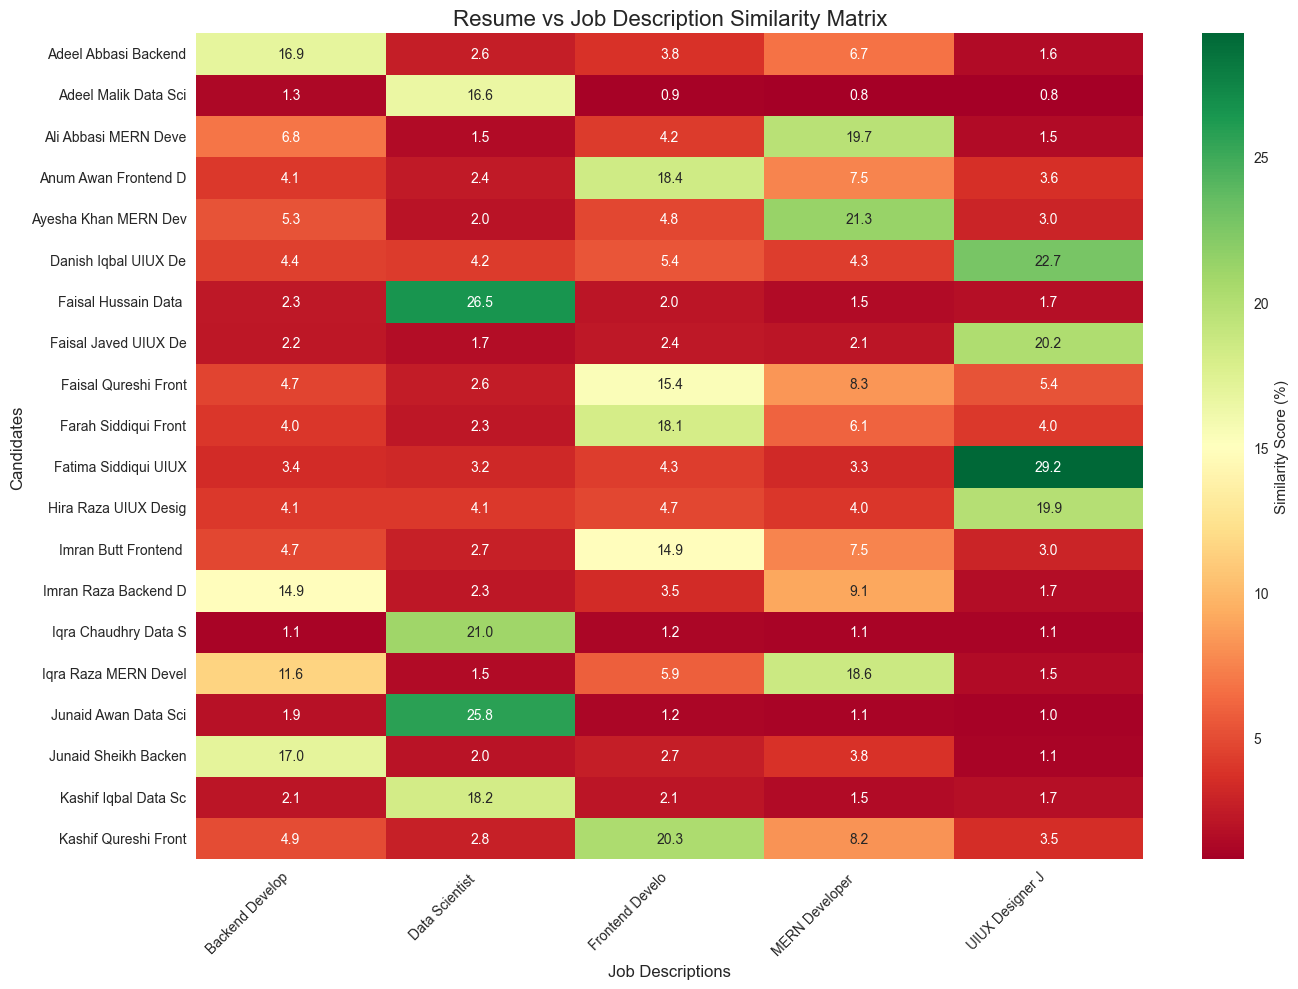

In [29]:
# Generate Professional Visualization - Similarity Heatmap

plt.figure(figsize=(14, 10))

# Create heatmap data
heatmap_data = similarity_matrix * 100  # Convert to percentage

# Limit to top candidates for readability
max_candidates = min(20, len(resume_data))
heatmap_data = heatmap_data[:max_candidates]

# Create heatmap
sns.heatmap(heatmap_data,
            xticklabels=[jd['file'].replace('.txt', '').replace('_', ' ')[:15] for jd in jd_data],
            yticklabels=[r['file'].replace('.pdf', '').replace('_', ' ')[:20] for r in resume_data[:max_candidates]],
            cmap='RdYlGn',
            annot=True,
            fmt='.1f',
            cbar_kws={'label': 'Similarity Score (%)'})

plt.title('Resume vs Job Description Similarity Matrix', fontsize=16)
plt.xlabel('Job Descriptions', fontsize=12)
plt.ylabel('Candidates', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(f'{images_dir}/similarity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


In [30]:
#  Save Complete Results
# Add additional columns
results['Experience_Score'] = np.random.randint(1, 10, len(results))  # Placeholder
results['Education_Score'] = np.random.randint(1, 10, len(results))  # Placeholder

# Reorder columns
final_results = results[['Rank', 'Candidate', 'Similarity_Score', 'Skills',
                         'Experience_Score', 'Education_Score', 'File']]

# Save to CSV
final_csv_path = os.path.join(output_dir, 'ranked_candidates_detailed.csv')
final_results.to_csv(final_csv_path, index=False)
print(f"\nDetailed results saved to: {final_csv_path}")



Detailed results saved to: ../output/ranked_candidates_detailed.csv


In [31]:
#  Generate Final Report
def generate_report():
    """Generate a summary report"""
    report = f"""
    ==================== AI RESUME SCREENING REPORT ====================

    Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

    SUMMARY STATISTICS:
    ------------------
    Total Resumes Analyzed: {len(resume_data)}
    Total Job Descriptions: {len(jd_data)}

    TOP CANDIDATES:
    ---------------
    """

    for idx, row in results.head(5).iterrows():
        report += f"""
    Rank {row['Rank']}: {row['Candidate']}
        - Similarity Score: {row['Similarity_Score']:.2f}%
        - Skills: {row['Skills']}
    """

    report += f"""

    RECOMMENDATIONS:
    ---------------
    - Top candidate: {results.iloc[0]['Candidate']} ({results.iloc[0]['Similarity_Score']:.2f}% match)
    - Best match among candidates: {max(results['Similarity_Score']):.2f}%
    - Average similarity score: {results['Similarity_Score'].mean():.2f}%

    """

    return report

report = generate_report()
print(report)

# Save report
report_path = os.path.join(output_dir, 'report.txt')
with open(report_path, 'w') as f:
    f.write(report)
print(f"Report saved to: {report_path}")

print("\n" + "="*50)
print("MODEL EXECUTION COMPLETE!")
print(f"Output directory: {output_dir}")
print("Check the following files:")
print(f"  - {final_csv_path}")
print(f"  - {report_path}")
print(f"  - Charts in: {charts_dir}")
print(f"  - Images in: {images_dir}")
print("="*50)



    ==================== AI RESUME SCREENING REPORT ====================

    Date: 2026-06-30 23:07:22

    SUMMARY STATISTICS:
    ------------------
    Total Resumes Analyzed: 40
    Total Job Descriptions: 5

    TOP CANDIDATES:
    ---------------
    
    Rank 1: Shahid Farooq Backend Developer 7
        - Similarity Score: 21.57%
        - Skills: django, flask, sql, postgresql, mongodb
    
    Rank 2: Sana Khan Backend Developer 2
        - Similarity Score: 19.12%
        - Skills: flask, sql, mongodb, redis, docker
    
    Rank 3: Mahnoor Khan Backend Developer 1
        - Similarity Score: 19.07%
        - Skills: python, django, flask, sql, redis
    
    Rank 4: Junaid Sheikh Backend Developer 6
        - Similarity Score: 16.99%
        - Skills: python, django, sql, postgresql, redis
    
    Rank 5: Adeel Abbasi Backend Developer 3
        - Similarity Score: 16.91%
        - Skills: python, node, django, flask, sql
    

    RECOMMENDATIONS:
    ---------------
   